In [1]:
# Correlation & Regression Analysis - Week 4 Day 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Create dataset

data = {
    "Advertising_Spend": [10, 12, 15, 18, 20, 22, 25, 28, 30, 32,
                          35, 38, 40, 42, 45, 48, 50, 52, 55, 58],
    "Sales": [25, 28, 32, 35, 38, 41, 45, 48, 52, 55,
              58, 61, 64, 67, 70, 74, 77, 80, 84, 88]
}

df = pd.DataFrame(data)

print("Dataset created successfully")
display(df)

Dataset created successfully


,Advertising_Spend,Sales
0,10,25
1,12,28
2,15,32
3,18,35
4,20,38
5,22,41
6,25,45
7,28,48
8,30,52
9,32,55


In [3]:
# Basic data exploration

print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (20, 2)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Advertising_Spend  20 non-null     int64
 1   Sales              20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes

Descriptive Statistics:


,Advertising_Spend,Sales
count,20.000000,20.000000
mean,33.750000,56.100000
std,14.839049,19.292486
min,10.000000,25.000000
25%,21.500000,40.250000
50%,33.500000,56.500000
75%,45.750000,71.000000
max,58.000000,88.000000


In [4]:
# Pearson correlation

pearson_correlation = df["Advertising_Spend"].corr(
    df["Sales"],
    method="pearson"
)

print("Pearson Correlation:", round(pearson_correlation, 4))

Pearson Correlation: 0.9997


In [5]:
# Spearman correlation

spearman_correlation = df["Advertising_Spend"].corr(
    df["Sales"],
    method="spearman"
)

print("Spearman Correlation:", round(spearman_correlation, 4))

Spearman Correlation: 1.0


In [6]:
# Correlation matrix

correlation_matrix = df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Advertising_Spend,Sales
Advertising_Spend,1.000000,0.999658
Sales,0.999658,1.000000


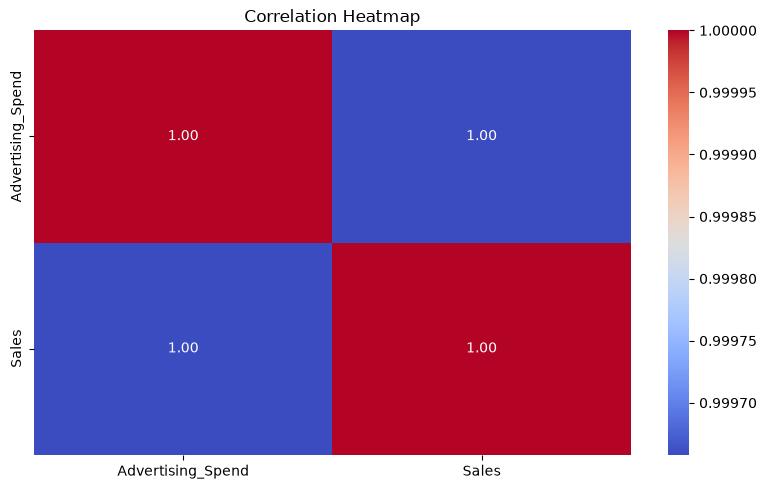

In [7]:
# Correlation heatmap

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

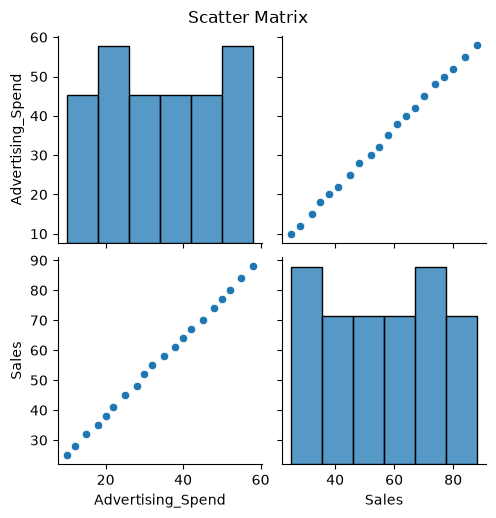

In [8]:
# Scatter matrix

sns.pairplot(df)

plt.suptitle("Scatter Matrix", y=1.02)
plt.show()

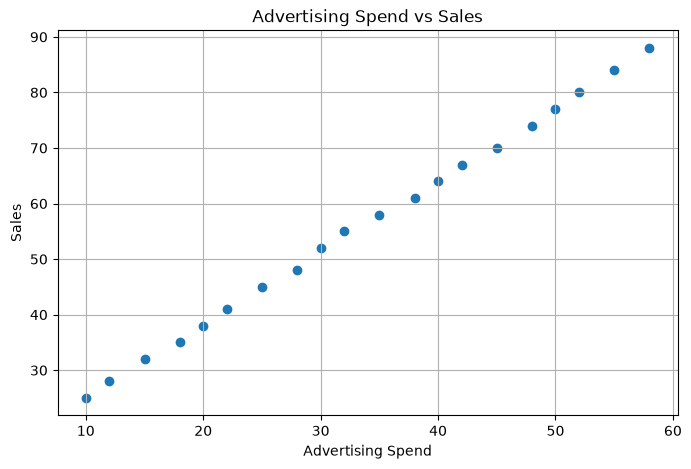

In [9]:
# Scatter plot

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Advertising_Spend"],
    df["Sales"]
)

plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Advertising Spend vs Sales")
plt.grid(True)
plt.show()

In [10]:
# Prepare independent and dependent variables

X = df[["Advertising_Spend"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [11]:
# Build linear regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear regression model trained successfully")
print("Intercept:", round(model.intercept_, 4))
print("Coefficient:", round(model.coef_[0], 4))

Linear regression model trained successfully
Intercept: 12.2244
Coefficient: 1.3009


In [12]:
# Make predictions

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

display(results)

,Actual Sales,Predicted Sales
0,25,25.233635
1,80,79.872305
2,74,74.668622
3,28,27.835477


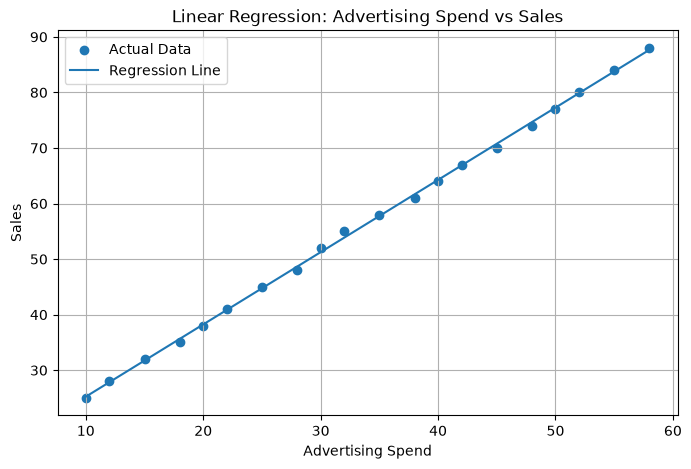

In [13]:
# Plot regression line

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Linear Regression: Advertising Spend vs Sales")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Model evaluation

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation Metrics")
print("------------------------")
print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 4))
print("RMSE     :", round(rmse, 4))

Model Evaluation Metrics
------------------------
R² Score : 0.9998
MAE      : 0.2986
RMSE     : 0.3691


In [15]:
# Interpret model metrics

print("R² measures how much of the variation in Sales is explained by Advertising Spend.")
print("MAE represents the average absolute prediction error.")
print("RMSE represents the square root of the average squared prediction error.")

print("\nR² Score:", round(r2, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

R² measures how much of the variation in Sales is explained by Advertising Spend.
MAE represents the average absolute prediction error.
RMSE represents the square root of the average squared prediction error.

R² Score: 0.9998
MAE: 0.2986
RMSE: 0.3691


In [16]:
# Calculate residuals

residuals = y_test - y_pred

residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals.values
})

display(residual_df)

,Actual,Predicted,Residual
0,25,25.233635,-0.233635
1,80,79.872305,0.127695
2,74,74.668622,-0.668622
3,28,27.835477,0.164523


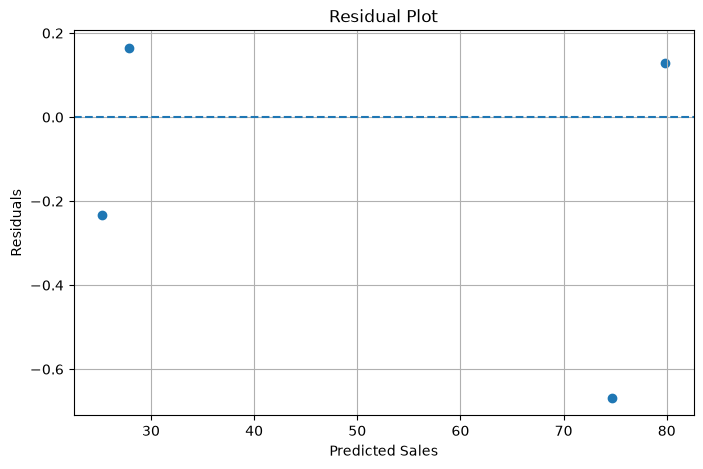

In [17]:
# Residual plot

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

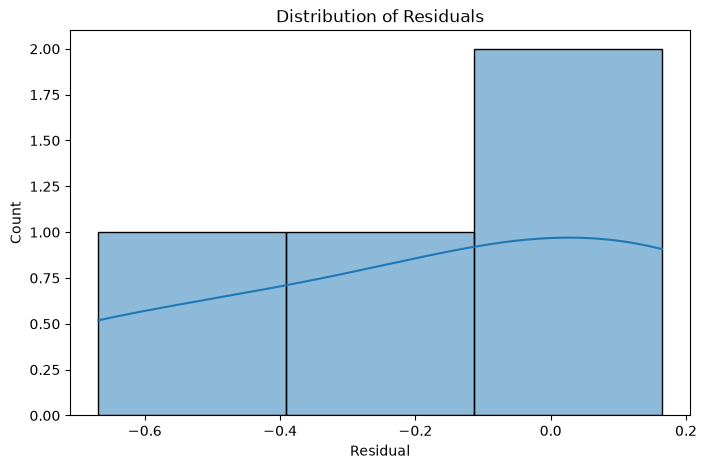

In [18]:
# Residual distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

In [19]:
# Check basic linear regression assumptions

print("Linear Regression Assumptions")
print("-----------------------------")
print("1. Linearity: Advertising Spend and Sales should have a linear relationship.")
print("2. Independence: Observations should be independent.")
print("3. Homoscedasticity: Residuals should have approximately constant variance.")
print("4. Normality: Residuals should be approximately normally distributed.")

print("\nThe scatter plot and residual plot can be used to visually assess these assumptions.")

Linear Regression Assumptions
-----------------------------
1. Linearity: Advertising Spend and Sales should have a linear relationship.
2. Independence: Observations should be independent.
3. Homoscedasticity: Residuals should have approximately constant variance.
4. Normality: Residuals should be approximately normally distributed.

The scatter plot and residual plot can be used to visually assess these assumptions.


In [21]:
# Final conclusion

print("Conclusion")
print("----------")

print(
    f"Pearson correlation between Advertising Spend and Sales: "
    f"{pearson_correlation:.4f}"
)

print(
    f"Spearman correlation between Advertising Spend and Sales: "
    f"{spearman_correlation:.4f}"
)

print(
    f"R² score of the linear regression model: {r2:.4f}"
)

print(
    f"Mean Absolute Error (MAE): {mae:.4f}"
)

print(
    f"Root Mean Squared Error (RMSE): {rmse:.4f}"
)

print(
    "\nThe correlation results indicate a strong positive relationship "
    "between Advertising Spend and Sales. The linear regression model "
    "is used to estimate Sales based on Advertising Spend."
)

Conclusion
----------
Pearson correlation between Advertising Spend and Sales: 0.9997
Spearman correlation between Advertising Spend and Sales: 1.0000
R² score of the linear regression model: 0.9998
Mean Absolute Error (MAE): 0.2986
Root Mean Squared Error (RMSE): 0.3691

The correlation results indicate a strong positive relationship between Advertising Spend and Sales. The linear regression model is used to estimate Sales based on Advertising Spend.
